# Matplotlib Hands-On Exercises

A comprehensive guide to creating visualizations with matplotlib.

In [39]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.patches import Circle
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")


All libraries imported successfully!


## 1. Getting Started

### Basic matplotlib workflow:
1. Import matplotlib.pyplot
2. Create figure and axes
3. Plot data
4. Customize appearance
5. Display or save


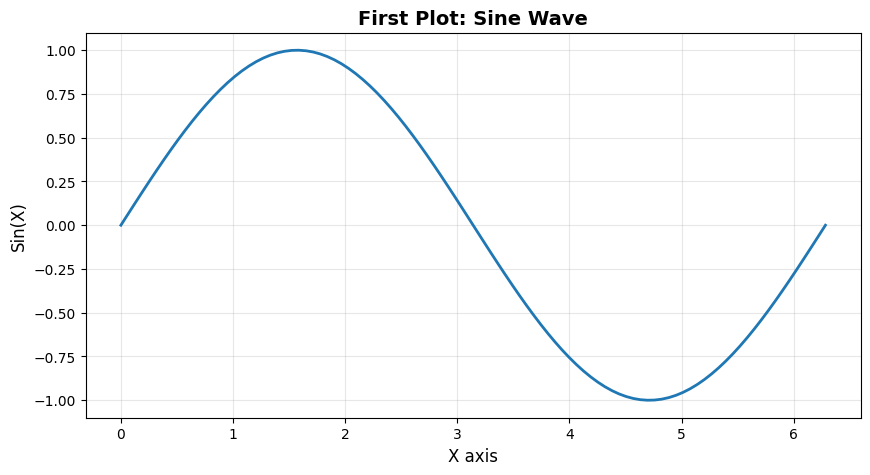

In [40]:
# Simple first plot - sine wave
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, linewidth=2)
plt.xlabel('X axis', fontsize=12)
plt.ylabel('Sin(X)', fontsize=12)
plt.title('First Plot: Sine Wave', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()


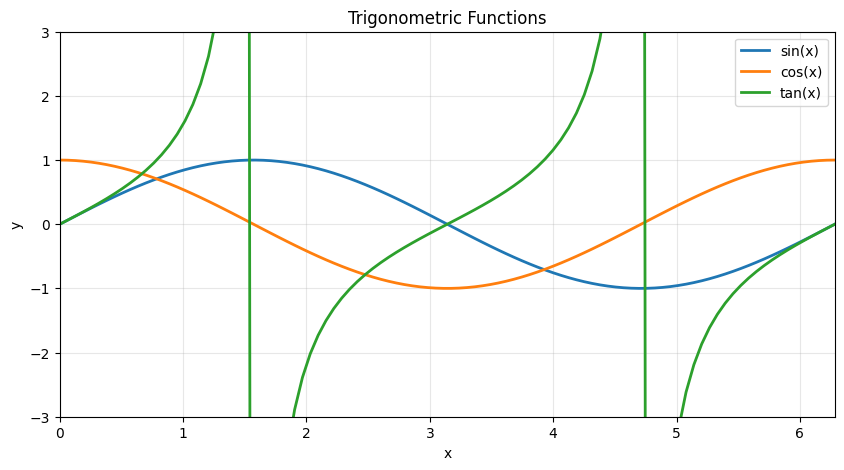

In [41]:
# Quick multi-line plot
x = np.linspace(0, 2*np.pi, 100)
plt.figure(figsize=(10, 5))
plt.plot(x, np.sin(x), label='sin(x)', linewidth=2)
plt.plot(x, np.cos(x), label='cos(x)', linewidth=2)
plt.plot(x, np.tan(x), label='tan(x)', linewidth=2)
plt.xlim(0, 2*np.pi)
plt.ylim(-3, 3)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Trigonometric Functions')
plt.grid(True, alpha=0.3)
plt.show()


## 2. The Two Interfaces

Matplotlib has two APIs:
- **Pyplot interface**: Simple, MATLAB-like (stateful)
- **Object-oriented interface**: More control, recommended for complex plots


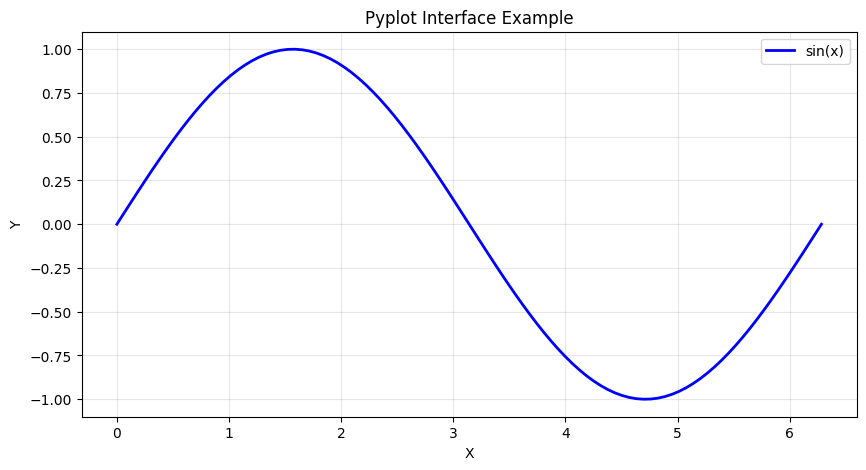

In [42]:
# Pyplot interface (stateful)
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'b-', linewidth=2, label='sin(x)')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Pyplot Interface Example')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


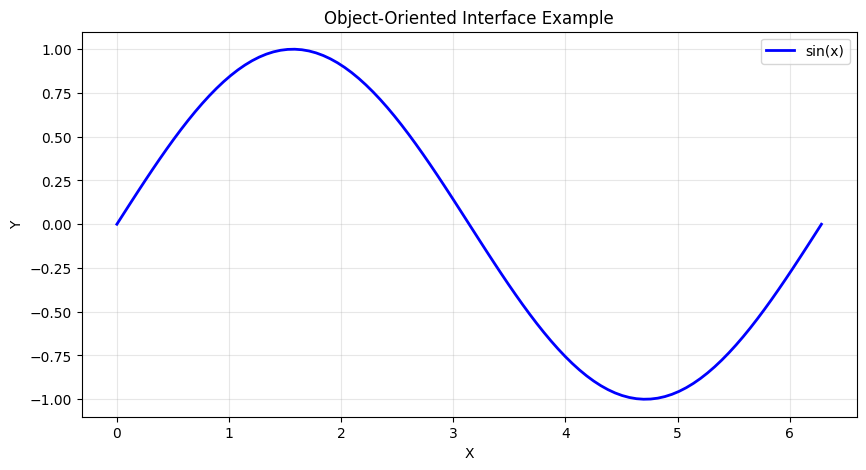

In [43]:
# Object-oriented interface (preferred)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2, label='sin(x)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Object-Oriented Interface Example')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. Line Plots

Line plots are fundamental for visualizing continuous data.


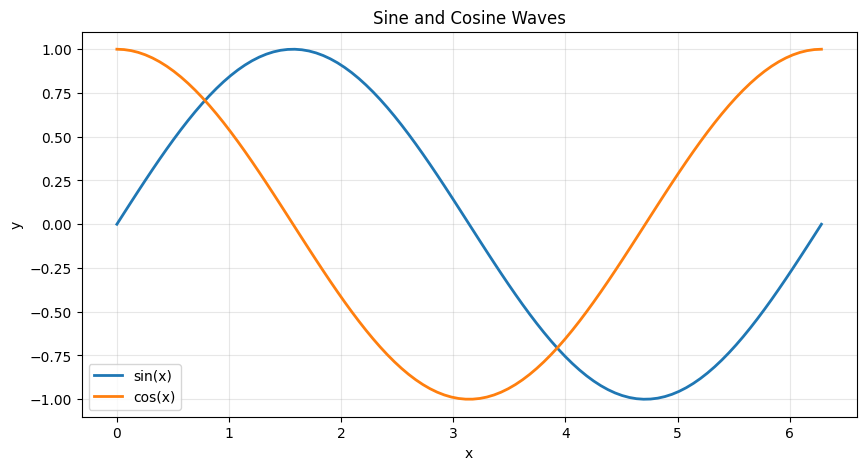

In [44]:
# Basic sine and cosine waves
x = np.linspace(0, 2*np.pi, 100)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Sine and Cosine Waves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


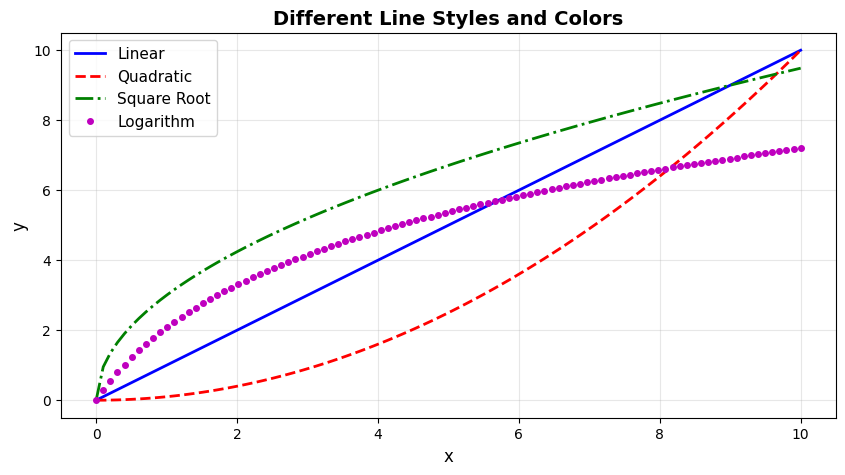

In [45]:
# Multiple lines with different colors and styles
x = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, x, 'b-', linewidth=2, label='Linear')
ax.plot(x, x**2/10, 'r--', linewidth=2, label='Quadratic')
ax.plot(x, np.sqrt(x)*3, 'g-.', linewidth=2, label='Square Root')
ax.plot(x, np.log(x+1)*3, 'mo', linewidth=2, markersize=4, label='Logarithm')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Different Line Styles and Colors', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()


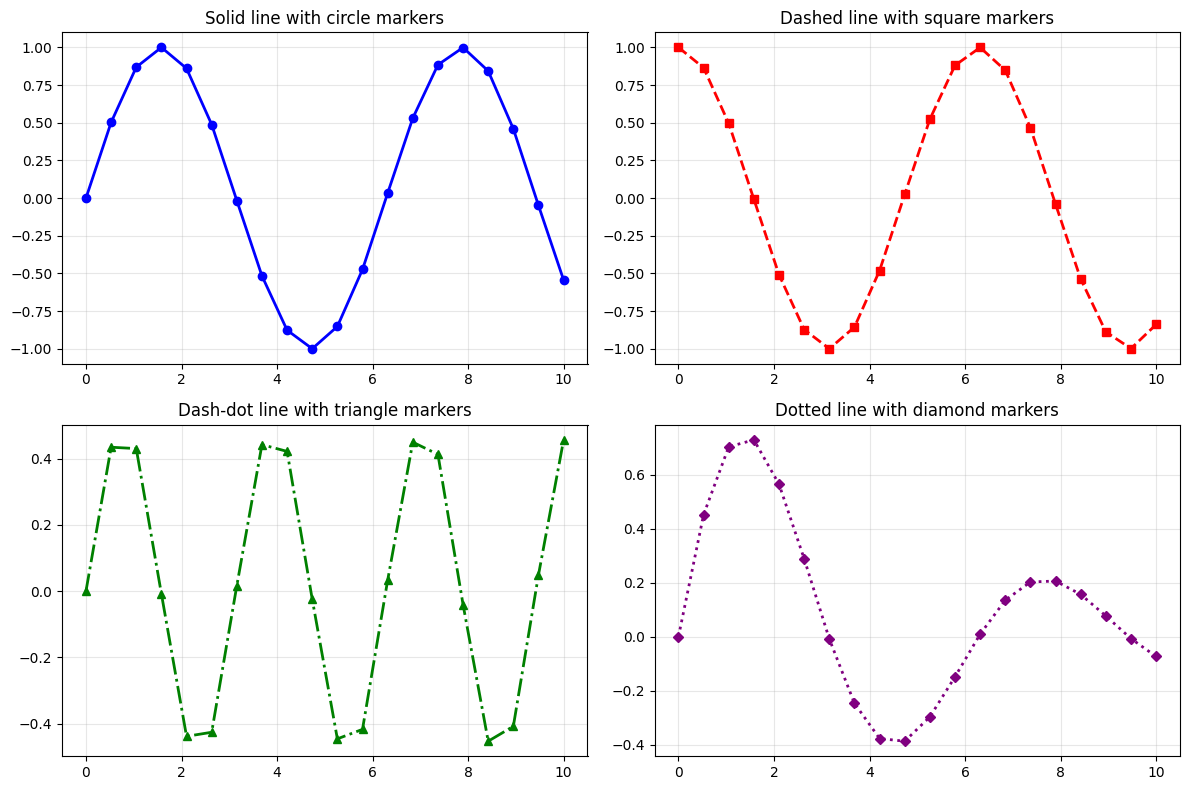

In [46]:
# Line styles and markers demonstration
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.linspace(0, 10, 20)

# Solid line
ax = axes[0, 0]
ax.plot(x, np.sin(x), 'o-', color='blue', linewidth=2, markersize=6)
ax.set_title('Solid line with circle markers')
ax.grid(True, alpha=0.3)

# Dashed line
ax = axes[0, 1]
ax.plot(x, np.cos(x), 's--', color='red', linewidth=2, markersize=6)
ax.set_title('Dashed line with square markers')
ax.grid(True, alpha=0.3)

# Dash-dot line
ax = axes[1, 0]
ax.plot(x, np.sin(x)*np.cos(x), '^-.', color='green', linewidth=2, markersize=6)
ax.set_title('Dash-dot line with triangle markers')
ax.grid(True, alpha=0.3)

# Dotted line
ax = axes[1, 1]
ax.plot(x, np.exp(-x/5)*np.sin(x), 'D:', color='purple', linewidth=2, markersize=5)
ax.set_title('Dotted line with diamond markers')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


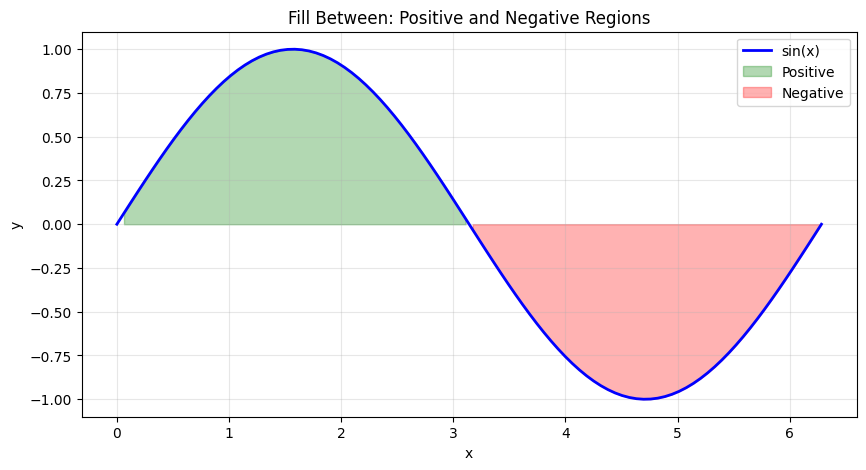

In [47]:
# Fill between for positive/negative regions
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2, label='sin(x)')

# Fill where y > 0
ax.fill_between(x, 0, y, where=(y > 0), alpha=0.3, color='green', label='Positive')
# Fill where y < 0
ax.fill_between(x, 0, y, where=(y < 0), alpha=0.3, color='red', label='Negative')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Fill Between: Positive and Negative Regions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


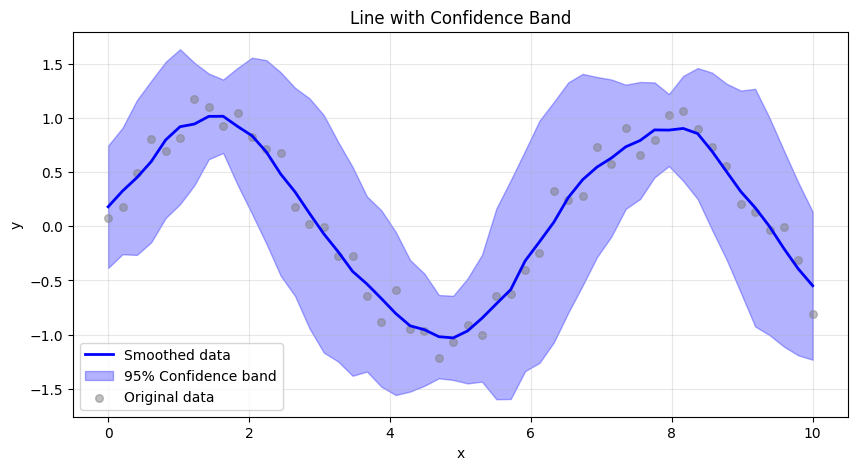

In [48]:
# Confidence band around line
x = np.linspace(0, 10, 50)
y = np.sin(x)
error = np.random.normal(0, 0.15, size=len(x))
y_noisy = y + error

fig, ax = plt.subplots(figsize=(10, 5))

# Calculate rolling mean and std
from scipy.ndimage import uniform_filter1d
window = 5
y_smooth = uniform_filter1d(y_noisy, size=window, mode='nearest')
y_std = np.array([np.std(y_noisy[max(0, i-window):min(len(y_noisy), i+window)])
                   for i in range(len(y_noisy))])

ax.plot(x, y_smooth, 'b-', linewidth=2, label='Smoothed data')
ax.fill_between(x, y_smooth - 2*y_std, y_smooth + 2*y_std, alpha=0.3, color='blue',
                label='95% Confidence band')
ax.scatter(x, y_noisy, alpha=0.5, s=30, color='gray', label='Original data')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Line with Confidence Band')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 4. Bar Charts

Bar charts are ideal for comparing values across categories.


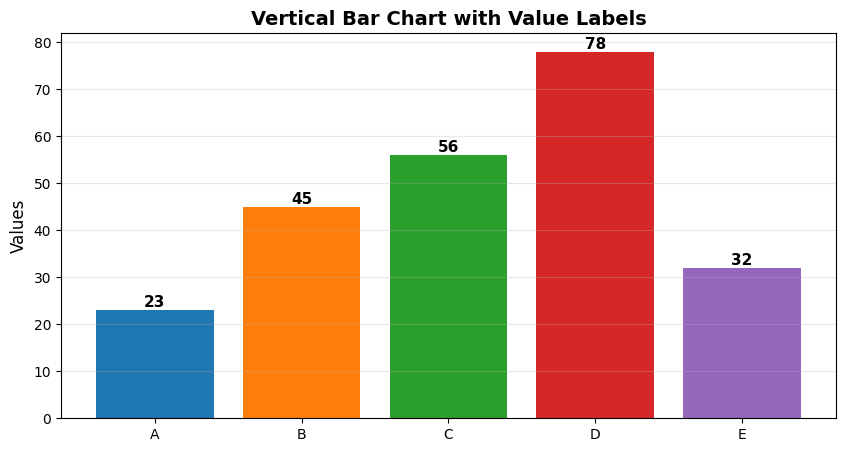

In [49]:
# Vertical bar chart with value labels
categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Add value labels on top of bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Values', fontsize=12)
ax.set_title('Vertical Bar Chart with Value Labels', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.show()


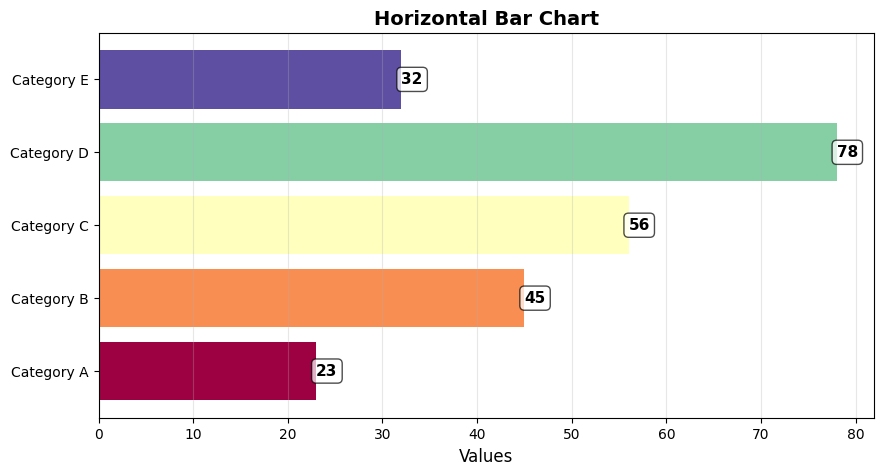

In [50]:
# Horizontal bar chart
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
values = [23, 45, 56, 78, 32]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(categories, values, color=plt.cm.Spectral(np.linspace(0, 1, len(categories))))

# Add value labels
for bar, value in zip(bars, values):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(value)}',
            ha='left', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlabel('Values', fontsize=12)
ax.set_title('Horizontal Bar Chart', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.show()


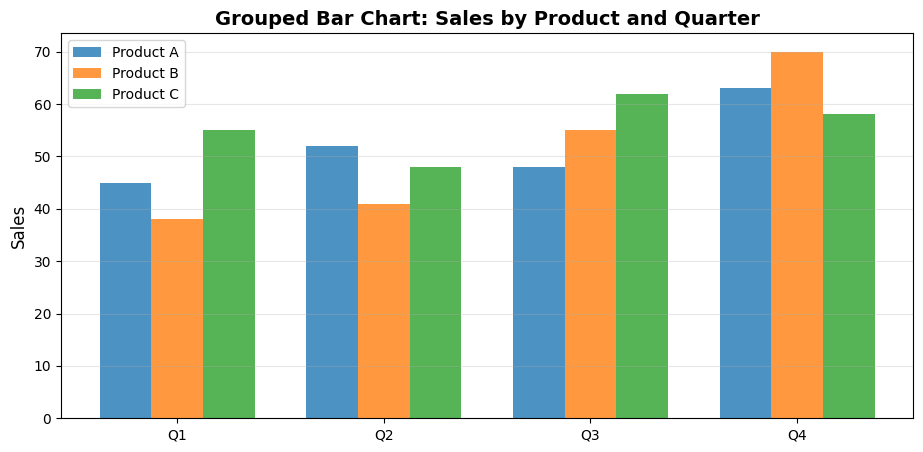

In [51]:
# Grouped bar chart
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [45, 52, 48, 63]
product_b = [38, 41, 55, 70]
product_c = [55, 48, 62, 58]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width, product_a, width, label='Product A', alpha=0.8)
bars2 = ax.bar(x, product_b, width, label='Product B', alpha=0.8)
bars3 = ax.bar(x + width, product_c, width, label='Product C', alpha=0.8)

ax.set_ylabel('Sales', fontsize=12)
ax.set_title('Grouped Bar Chart: Sales by Product and Quarter', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


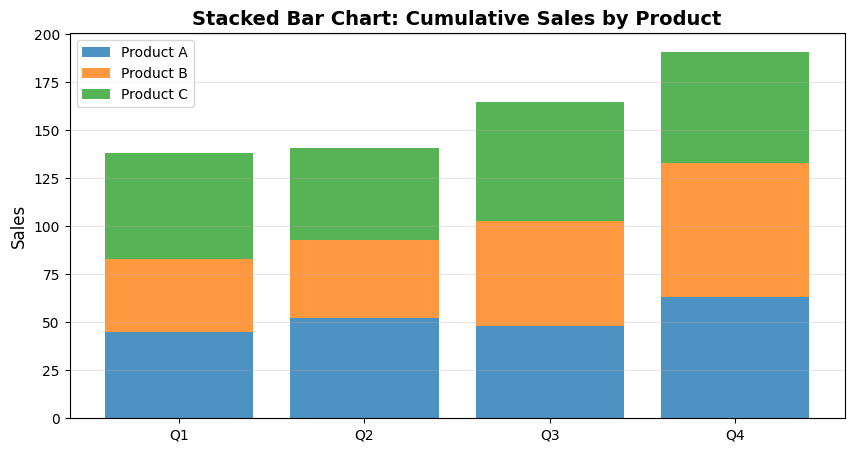

In [52]:
# Stacked bar chart
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [45, 52, 48, 63]
product_b = [38, 41, 55, 70]
product_c = [55, 48, 62, 58]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(categories, product_a, label='Product A', alpha=0.8)
ax.bar(categories, product_b, bottom=product_a, label='Product B', alpha=0.8)
ax.bar(categories, product_c,
       bottom=np.array(product_a)+np.array(product_b),
       label='Product C', alpha=0.8)

ax.set_ylabel('Sales', fontsize=12)
ax.set_title('Stacked Bar Chart: Cumulative Sales by Product', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


## 5. Scatter Plots

Scatter plots show the relationship between two continuous variables.


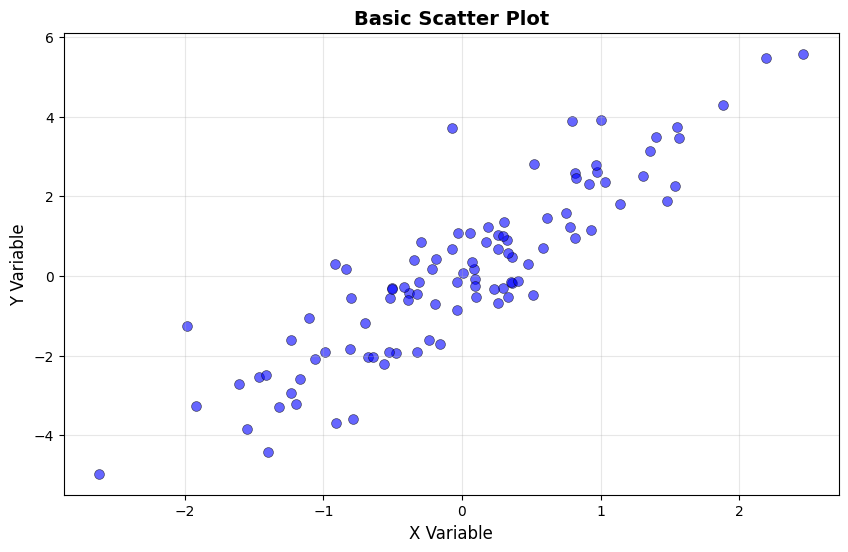

In [53]:
# Basic scatter plot
x = np.random.randn(100)
y = 2*x + np.random.randn(100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.6, s=50, color='blue', edgecolors='black', linewidth=0.5)
ax.set_xlabel('X Variable', fontsize=12)
ax.set_ylabel('Y Variable', fontsize=12)
ax.set_title('Basic Scatter Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()


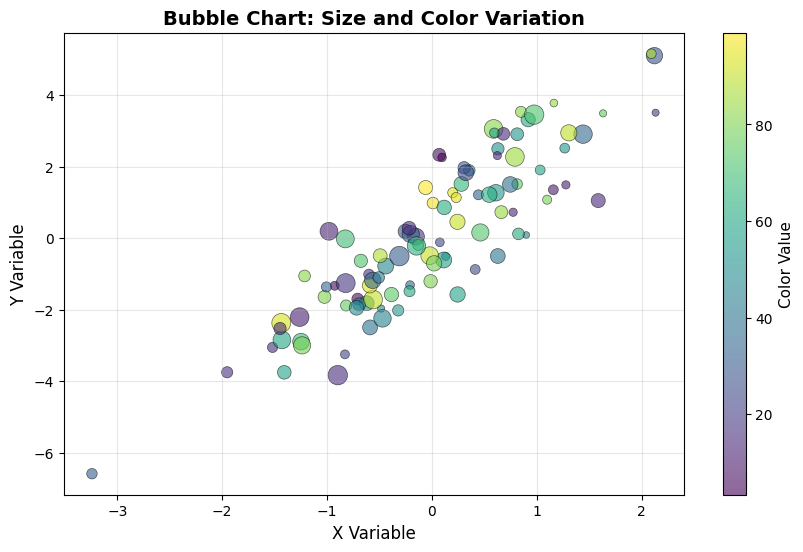

In [54]:
# Bubble chart: size and color variation
n_points = 100
x = np.random.randn(n_points)
y = 2*x + np.random.randn(n_points)
size = np.random.uniform(20, 200, n_points)
color = np.random.uniform(0, 100, n_points)

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(x, y, s=size, c=color, cmap='viridis', alpha=0.6,
                     edgecolors='black', linewidth=0.5)
ax.set_xlabel('X Variable', fontsize=12)
ax.set_ylabel('Y Variable', fontsize=12)
ax.set_title('Bubble Chart: Size and Color Variation', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Color Value', fontsize=11)

ax.grid(True, alpha=0.3)
plt.show()


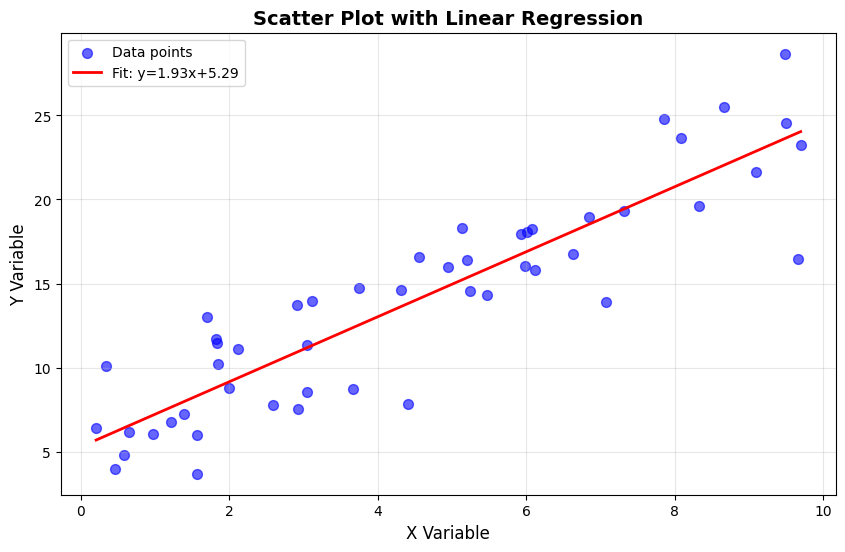

In [55]:
# Scatter plot with regression line
from numpy.polynomial import polynomial as P

np.random.seed(42)
x = np.random.uniform(0, 10, 50)
y = 2*x + 5 + np.random.normal(0, 3, 50)

# Fit polynomial
coeffs = np.polyfit(x, y, 1)
poly = np.poly1d(coeffs)
x_smooth = np.linspace(x.min(), x.max(), 100)
y_fit = poly(x_smooth)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, alpha=0.6, s=50, color='blue', label='Data points')
ax.plot(x_smooth, y_fit, 'r-', linewidth=2, label=f'Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}')

ax.set_xlabel('X Variable', fontsize=12)
ax.set_ylabel('Y Variable', fontsize=12)
ax.set_title('Scatter Plot with Linear Regression', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


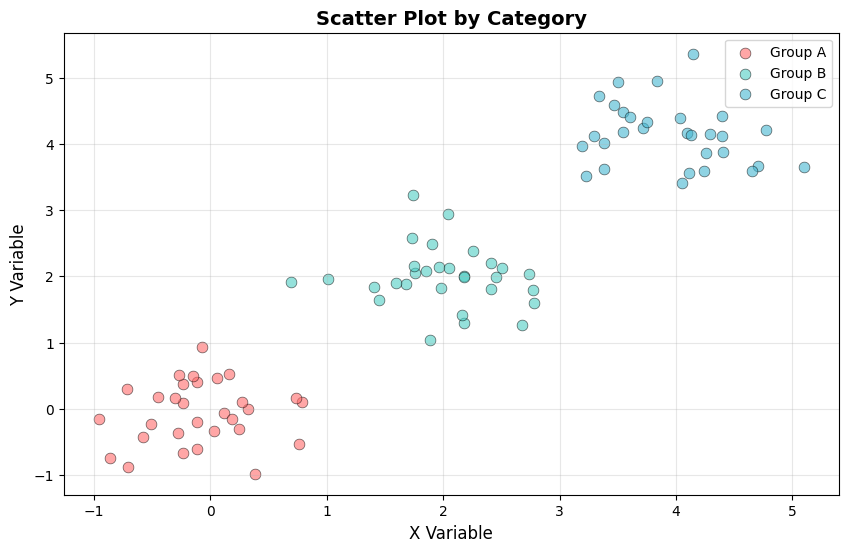

In [56]:
# Scatter plot by category
np.random.seed(42)
groups = ['Group A', 'Group B', 'Group C']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (group, color) in enumerate(zip(groups, colors)):
    x = np.random.normal(i*2, 0.5, 30)
    y = np.random.normal(i*2, 0.5, 30)
    ax.scatter(x, y, alpha=0.6, s=60, color=color, label=group, edgecolors='black', linewidth=0.5)

ax.set_xlabel('X Variable', fontsize=12)
ax.set_ylabel('Y Variable', fontsize=12)
ax.set_title('Scatter Plot by Category', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 6. Histograms

Histograms show the distribution of continuous data.


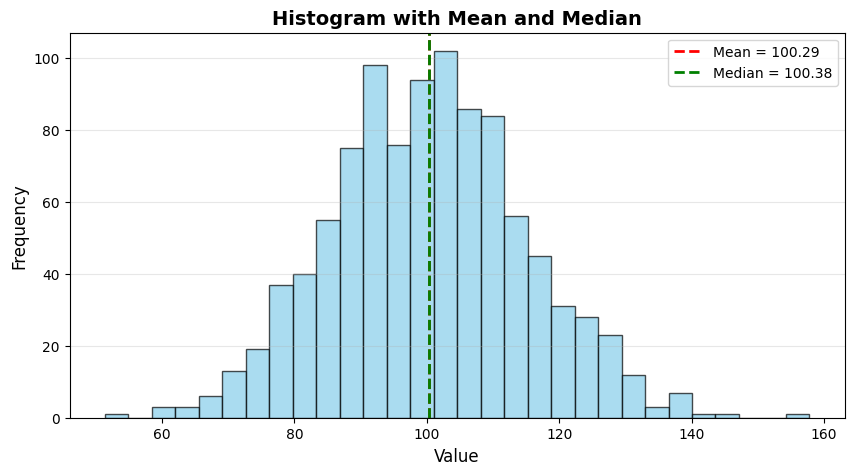

In [57]:
# Basic histogram with mean line
np.random.seed(42)
data = np.random.normal(100, 15, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Add mean line
mean_val = np.mean(data)
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')

# Add median line
median_val = np.median(data)
ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median = {median_val:.2f}')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Histogram with Mean and Median', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


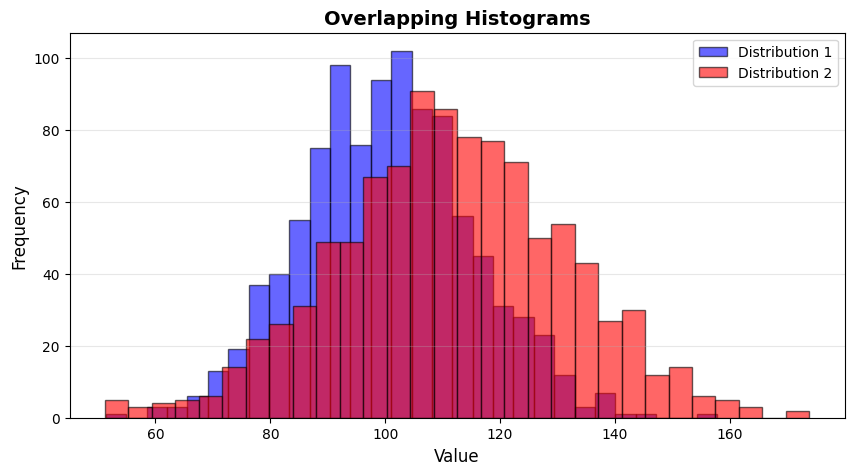

In [58]:
# Overlapping histograms
np.random.seed(42)
data1 = np.random.normal(100, 15, 1000)
data2 = np.random.normal(110, 20, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data1, bins=30, alpha=0.6, label='Distribution 1', color='blue', edgecolor='black')
ax.hist(data2, bins=30, alpha=0.6, label='Distribution 2', color='red', edgecolor='black')

ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Overlapping Histograms', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.show()


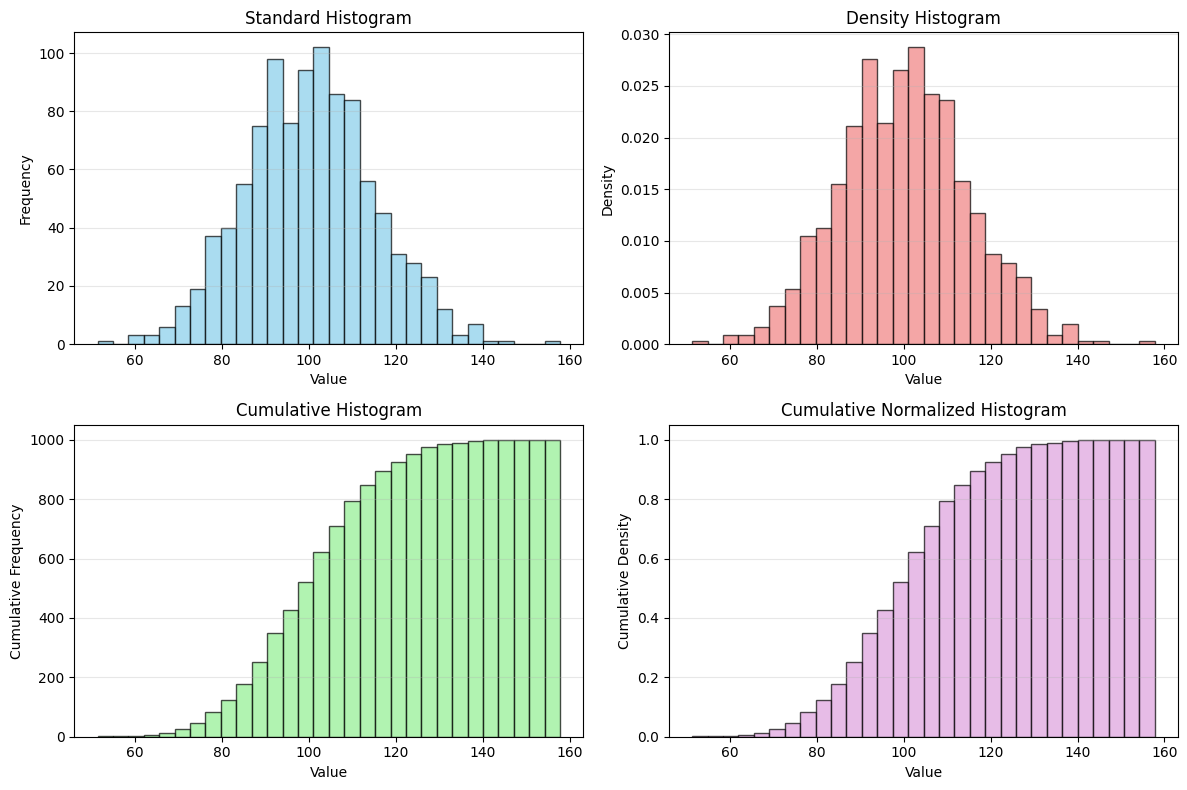

In [59]:
# Histogram types: standard, density, cumulative
np.random.seed(42)
data = np.random.normal(100, 15, 1000)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Standard histogram
ax = axes[0, 0]
ax.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_title('Standard Histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# Density histogram
ax = axes[0, 1]
ax.hist(data, bins=30, density=True, color='lightcoral', edgecolor='black', alpha=0.7)
ax.set_title('Density Histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3, axis='y')

# Cumulative histogram
ax = axes[1, 0]
ax.hist(data, bins=30, cumulative=True, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_title('Cumulative Histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Cumulative Frequency')
ax.grid(True, alpha=0.3, axis='y')

# Cumulative normalized
ax = axes[1, 1]
ax.hist(data, bins=30, cumulative=True, density=True, color='plum',
        edgecolor='black', alpha=0.7)
ax.set_title('Cumulative Normalized Histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Cumulative Density')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


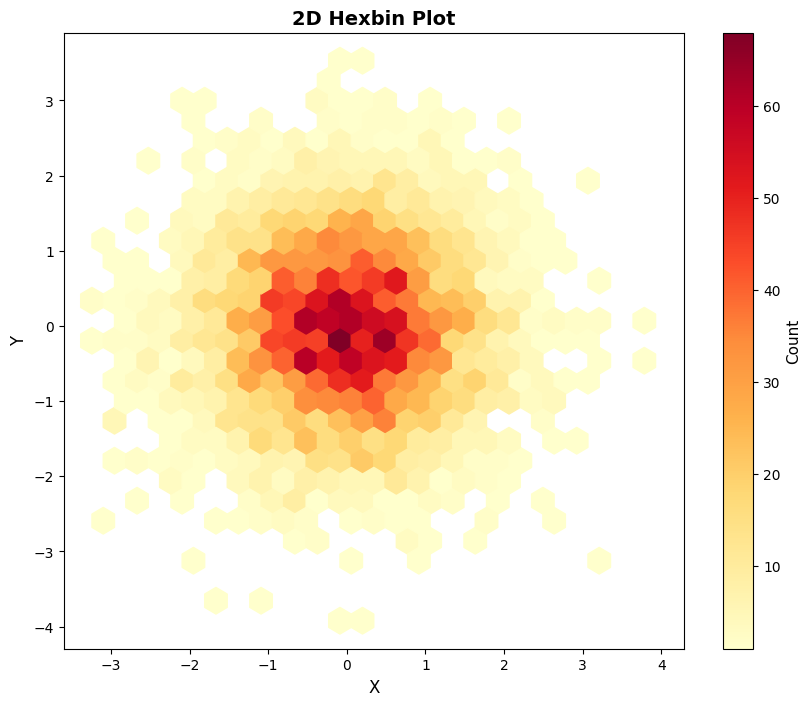

In [60]:
# 2D Hexbin plot
np.random.seed(42)
x = np.random.normal(0, 1, 5000)
y = np.random.normal(0, 1, 5000)

fig, ax = plt.subplots(figsize=(10, 8))
hexbin = ax.hexbin(x, y, gridsize=25, cmap='YlOrRd', mincnt=1)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('2D Hexbin Plot', fontsize=14, fontweight='bold')

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Count', fontsize=11)

plt.show()


## 7. Box Plots & Violin Plots

Box plots and violin plots show the distribution and quartiles of data.


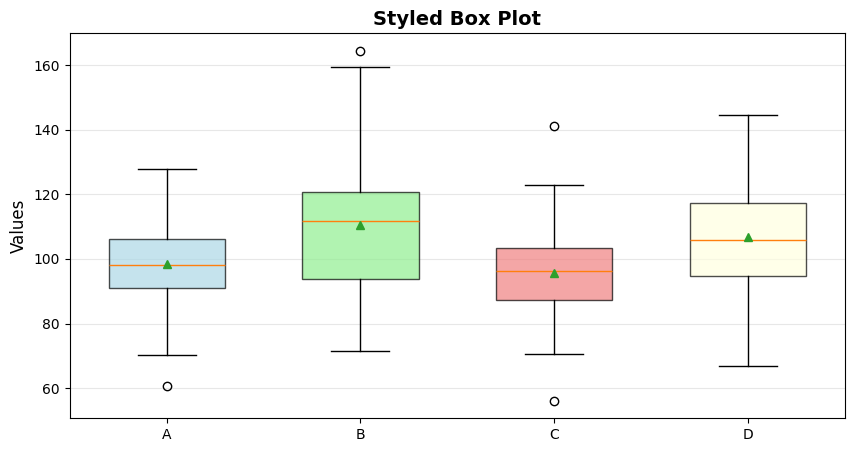

In [61]:
# Styled box plot
np.random.seed(42)
data = [np.random.normal(100, 15, 100),
        np.random.normal(110, 20, 100),
        np.random.normal(95, 12, 100),
        np.random.normal(105, 18, 100)]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data, labels=['A', 'B', 'C', 'D'], patch_artist=True,
                 widths=0.6, showmeans=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Values', fontsize=12)
ax.set_title('Styled Box Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.show()


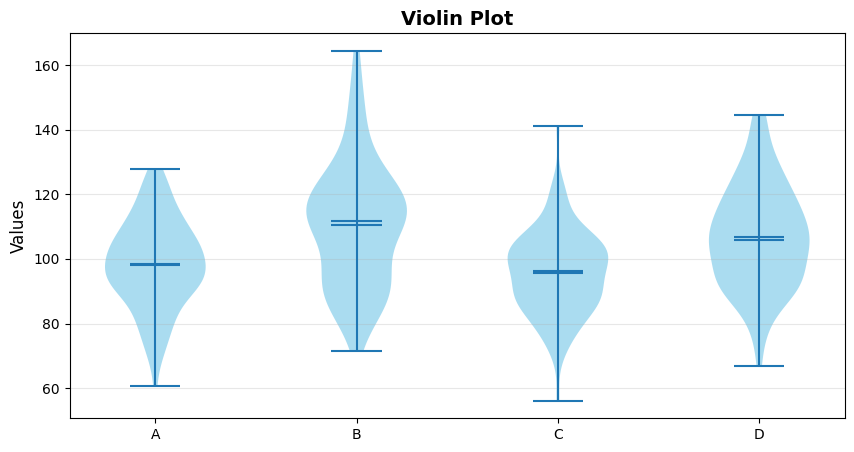

In [62]:
# Violin plot
np.random.seed(42)
data = [np.random.normal(100, 15, 100),
        np.random.normal(110, 20, 100),
        np.random.normal(95, 12, 100),
        np.random.normal(105, 18, 100)]

fig, ax = plt.subplots(figsize=(10, 5))
parts = ax.violinplot(data, positions=[1, 2, 3, 4], showmeans=True, showmedians=True)

for pc in parts['bodies']:
    pc.set_facecolor('skyblue')
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['A', 'B', 'C', 'D'])
ax.set_ylabel('Values', fontsize=12)
ax.set_title('Violin Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.show()


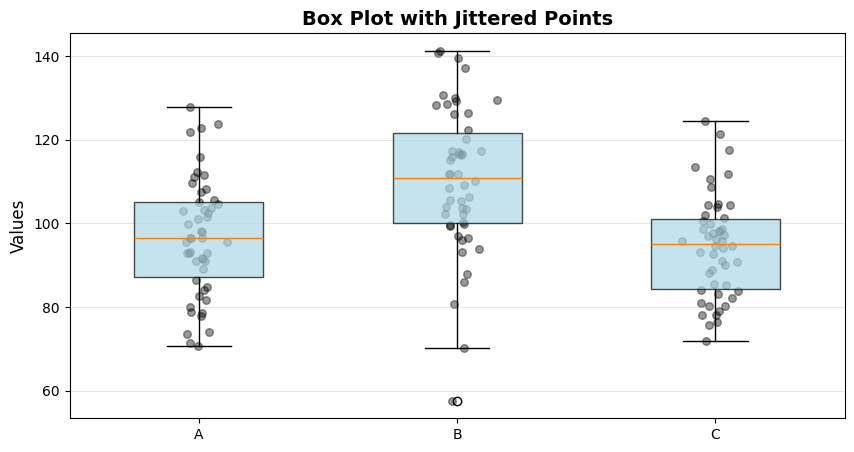

In [63]:
# Box plot with jittered points overlay
np.random.seed(42)
data = [np.random.normal(100, 15, 50),
        np.random.normal(110, 20, 50),
        np.random.normal(95, 12, 50)]

fig, ax = plt.subplots(figsize=(10, 5))

# Box plot
bp = ax.boxplot(data, labels=['A', 'B', 'C'], patch_artist=True, widths=0.5)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

# Add jittered points
for i, d in enumerate(data, 1):
    x = np.random.normal(i, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.4, s=30, color='black')

ax.set_ylabel('Values', fontsize=12)
ax.set_title('Box Plot with Jittered Points', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.show()


## 8. Pie Charts & Donut Charts

Pie charts show composition as proportions of a whole.


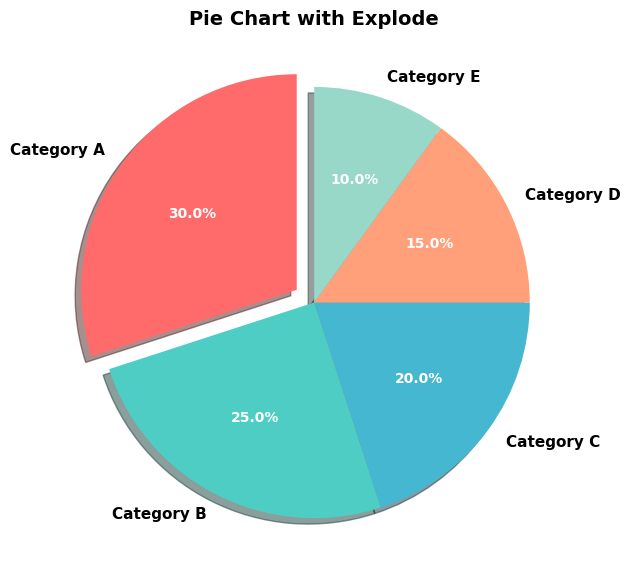

In [64]:
# Pie chart with explode and styled percentages
sizes = [30, 25, 20, 15, 10]
labels = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
explode = (0.1, 0, 0, 0, 0)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                    autopct='%1.1f%%', shadow=True, startangle=90)

# Style text
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Pie Chart with Explode', fontsize=14, fontweight='bold')
plt.show()


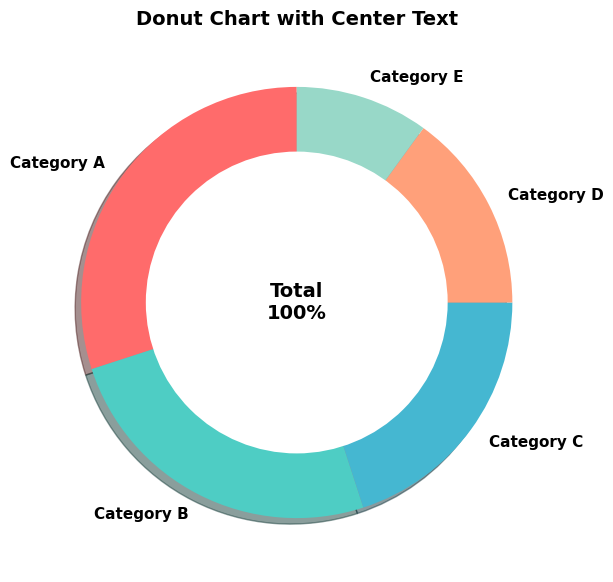

In [65]:
# Donut chart with center text
sizes = [30, 25, 20, 15, 10]
labels = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                    autopct='%1.1f%%', shadow=True, startangle=90)

# Draw circle for donut
centre_circle = Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Add center text
ax.text(0, 0, 'Total\n100%', ha='center', va='center', fontsize=14, fontweight='bold')

# Style text
for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Donut Chart with Center Text', fontsize=14, fontweight='bold')
plt.show()


## 9. Heatmaps

Heatmaps visualize data intensity using color.


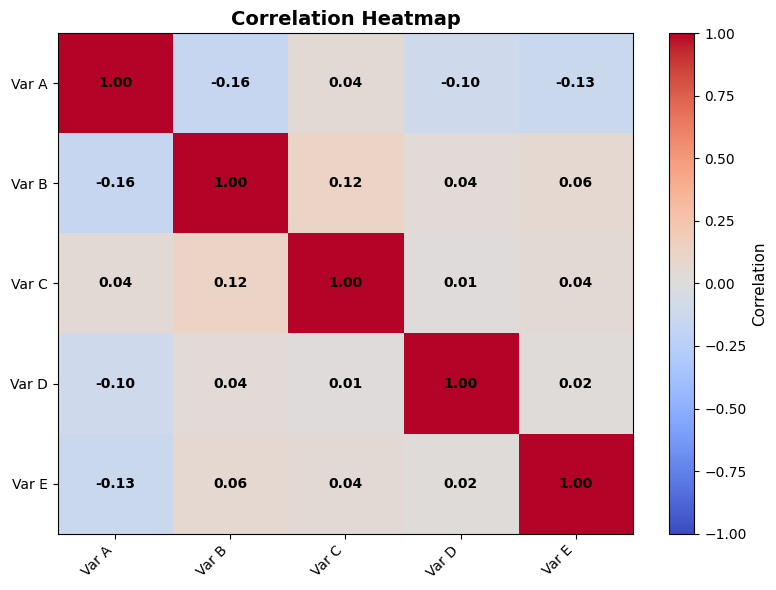

In [66]:
# Correlation heatmap with annotations
np.random.seed(42)
data = np.random.randn(100, 5)
df = pd.DataFrame(data, columns=['Var A', 'Var B', 'Var C', 'Var D', 'Var E'])
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Add text annotations
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', fontsize=11)

plt.tight_layout()
plt.show()


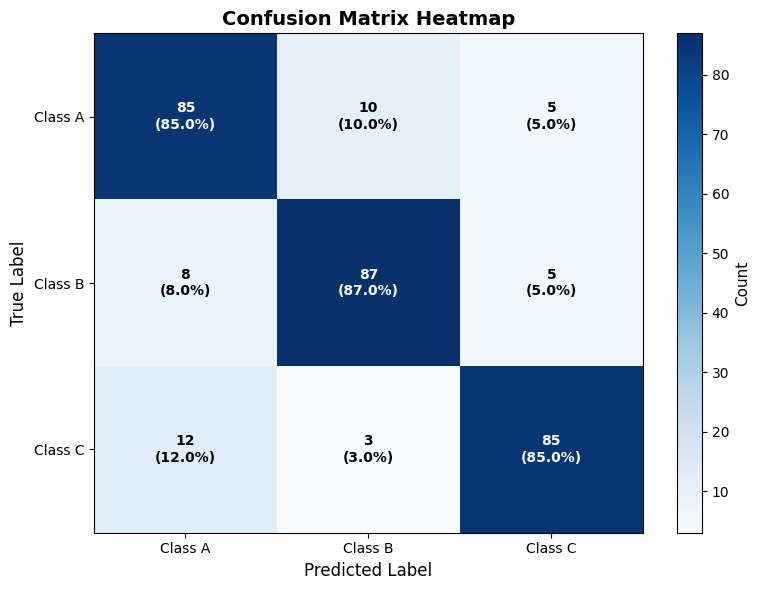

In [67]:
# Confusion matrix heatmap
np.random.seed(42)
cm = np.array([[85, 10, 5],
               [8, 87, 5],
               [12, 3, 85]])

labels = ['Class A', 'Class B', 'Class C']

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Add text annotations with percentages
for i in range(len(cm)):
    for j in range(len(cm)):
        count = cm[i, j]
        total = cm[i].sum()
        pct = 100 * count / total
        text = ax.text(j, i, f'{count}\n({pct:.1f}%)',
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max()/2 else "black",
                      fontsize=10, fontweight='bold')

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=11)

plt.tight_layout()
plt.show()


## 10. Subplots & Layouts

Creating multiple plots in a single figure.


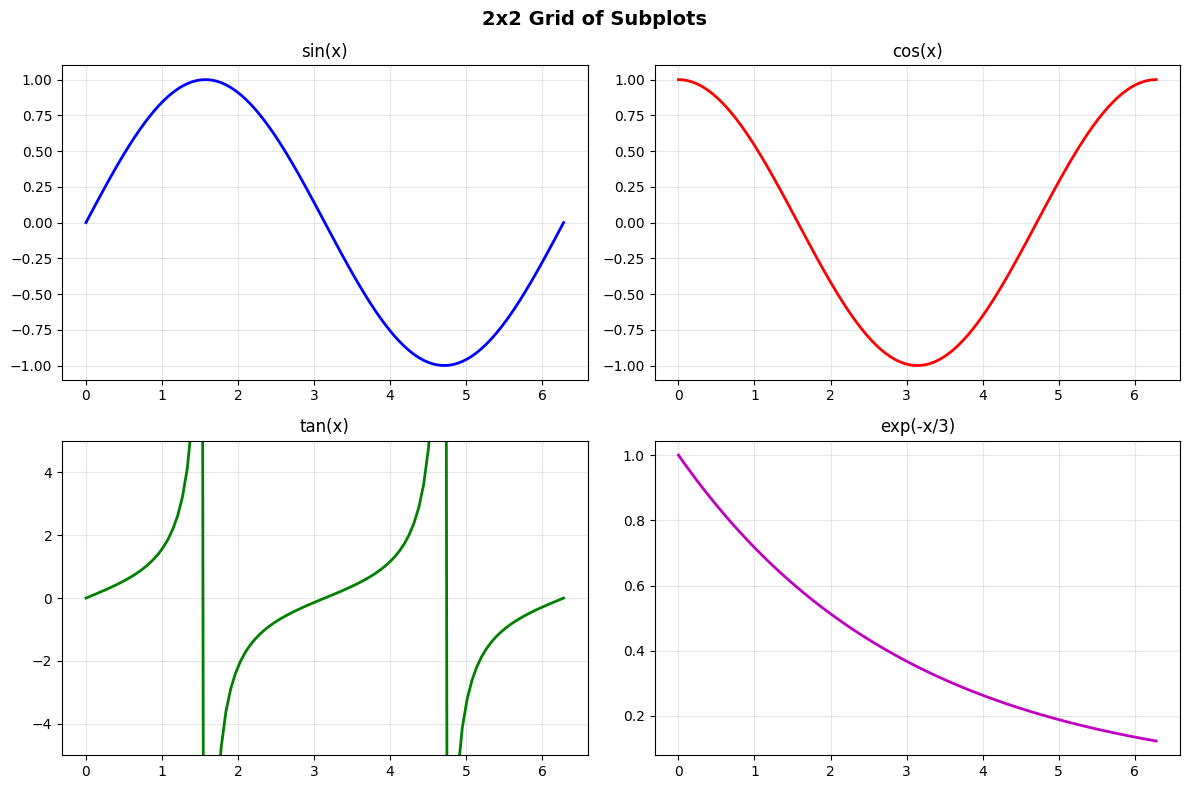

In [68]:
# 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(0, 2*np.pi, 100)

# Sine
axes[0, 0].plot(x, np.sin(x), 'b-', linewidth=2)
axes[0, 0].set_title('sin(x)')
axes[0, 0].grid(True, alpha=0.3)

# Cosine
axes[0, 1].plot(x, np.cos(x), 'r-', linewidth=2)
axes[0, 1].set_title('cos(x)')
axes[0, 1].grid(True, alpha=0.3)

# Tangent
axes[1, 0].plot(x, np.tan(x), 'g-', linewidth=2)
axes[1, 0].set_ylim(-5, 5)
axes[1, 0].set_title('tan(x)')
axes[1, 0].grid(True, alpha=0.3)

# Exponential
axes[1, 1].plot(x, np.exp(-x/3), 'm-', linewidth=2)
axes[1, 1].set_title('exp(-x/3)')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('2x2 Grid of Subplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


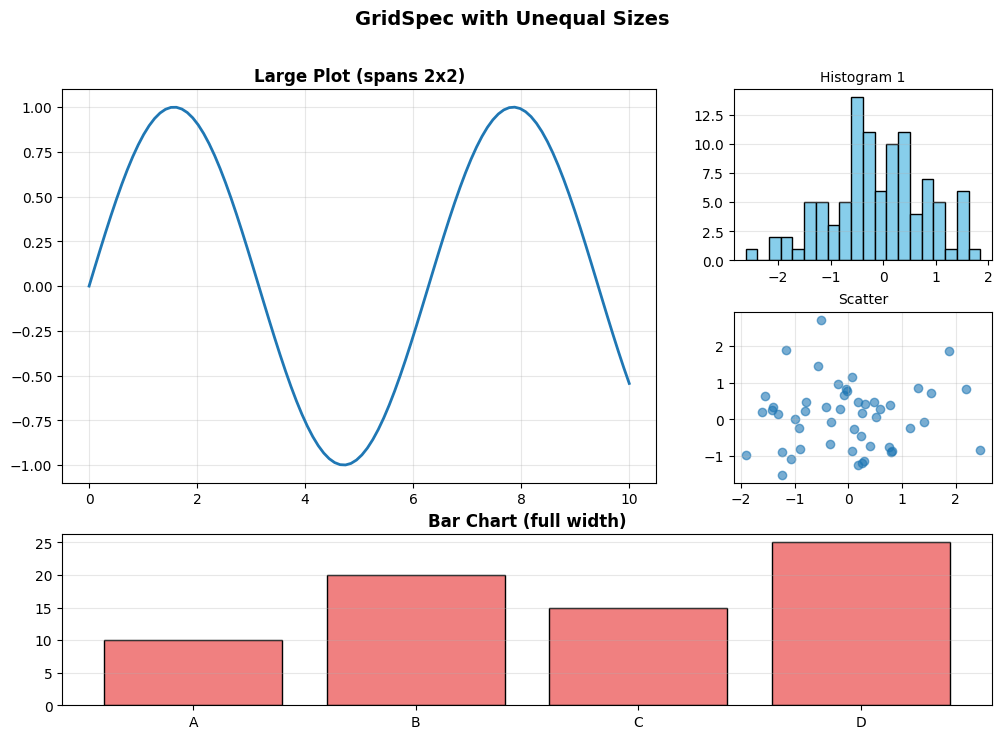

In [69]:
# GridSpec with unequal sizes
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Large plot on top left
ax1 = fig.add_subplot(gs[0:2, 0:2])
x = np.linspace(0, 10, 100)
ax1.plot(x, np.sin(x), linewidth=2)
ax1.set_title('Large Plot (spans 2x2)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Small plots on right
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(np.random.randn(100), bins=20, color='skyblue', edgecolor='black')
ax2.set_title('Histogram 1', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(gs[1, 2])
ax3.scatter(np.random.randn(50), np.random.randn(50), alpha=0.6)
ax3.set_title('Scatter', fontsize=10)
ax3.grid(True, alpha=0.3)

# Bottom plots
ax4 = fig.add_subplot(gs[2, :])
ax4.bar(['A', 'B', 'C', 'D'], [10, 20, 15, 25], color='lightcoral', edgecolor='black')
ax4.set_title('Bar Chart (full width)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

fig.suptitle('GridSpec with Unequal Sizes', fontsize=14, fontweight='bold')
plt.show()


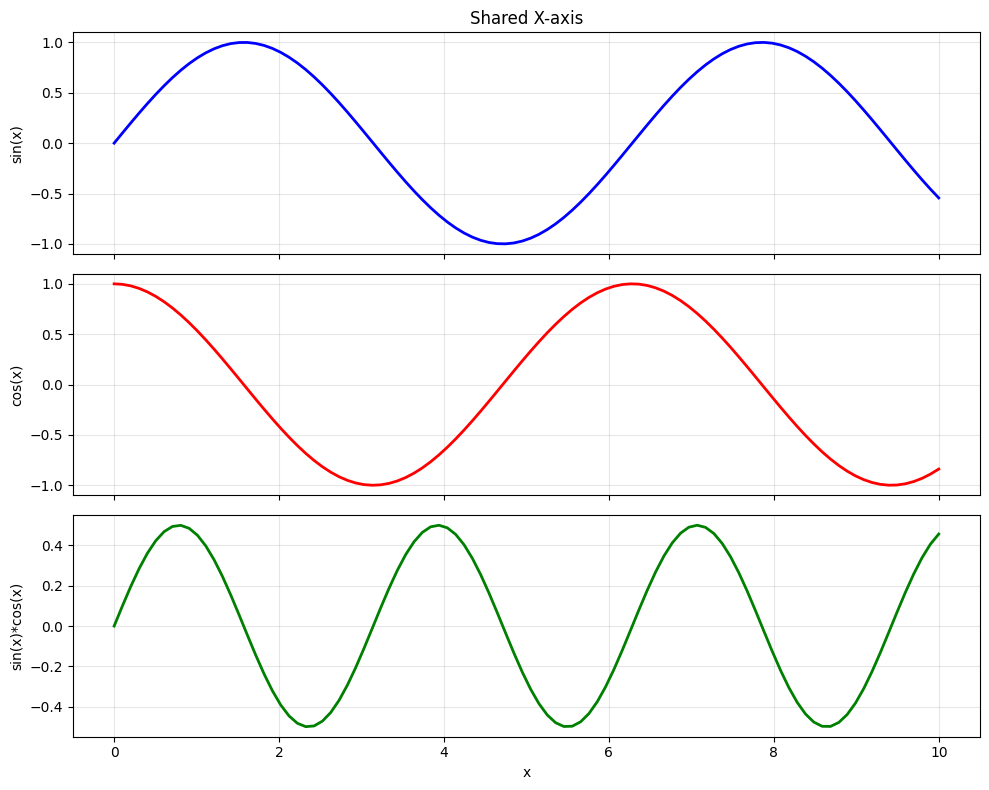

In [70]:
# Shared axes
x = np.linspace(0, 10, 100)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x, np.sin(x), 'b-', linewidth=2)
axes[0].set_ylabel('sin(x)')
axes[0].set_title('Shared X-axis')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, np.cos(x), 'r-', linewidth=2)
axes[1].set_ylabel('cos(x)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, np.sin(x) * np.cos(x), 'g-', linewidth=2)
axes[2].set_ylabel('sin(x)*cos(x)')
axes[2].set_xlabel('x')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


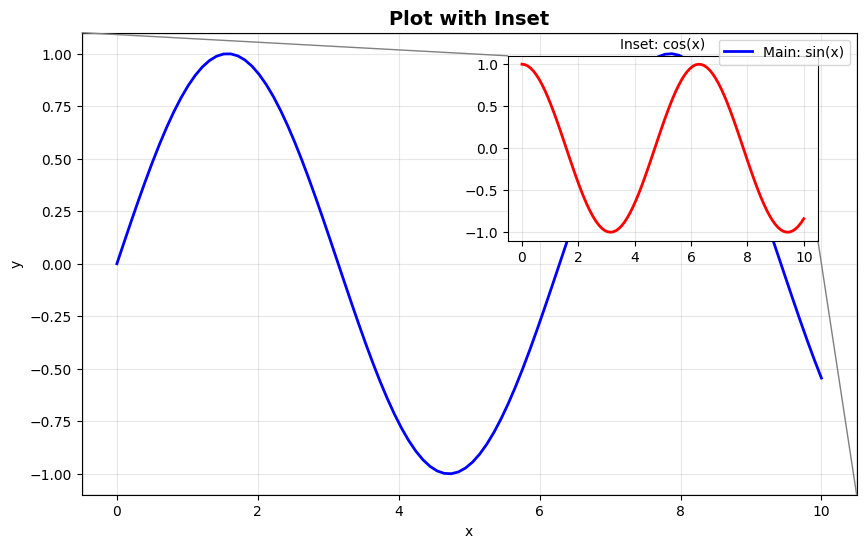

In [71]:
# Inset plot
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

fig, ax = plt.subplots(figsize=(10, 6))

# Main plot
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), 'b-', linewidth=2, label='Main: sin(x)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Plot with Inset', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Create inset
ax_inset = ax.inset_axes([0.55, 0.55, 0.4, 0.4])
ax_inset.plot(x, np.cos(x), 'r-', linewidth=2)
ax_inset.set_title('Inset: cos(x)', fontsize=10)
ax_inset.grid(True, alpha=0.3)

# Draw box around inset
mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

## 11. Styling & Customization

Customize appearance with styles, colors, and rcParams.


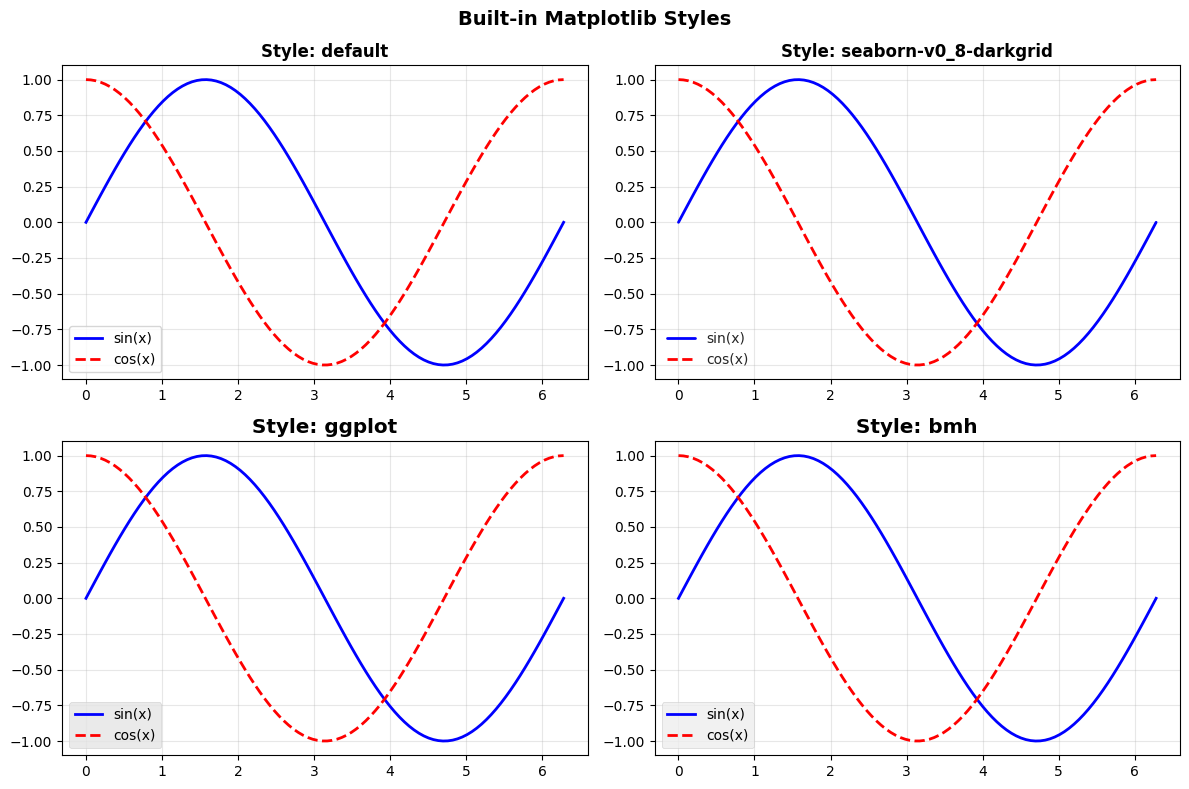

In [72]:
# Built-in styles demonstration
available_styles = ['default', 'seaborn-v0_8-darkgrid', 'ggplot', 'bmh']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
x = np.linspace(0, 2*np.pi, 100)

for ax, style in zip(axes.flat, available_styles):
    with plt.style.context(style):
        ax.plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
        ax.plot(x, np.cos(x), 'r--', linewidth=2, label='cos(x)')
        ax.set_title(f'Style: {style}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

fig.suptitle('Built-in Matplotlib Styles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


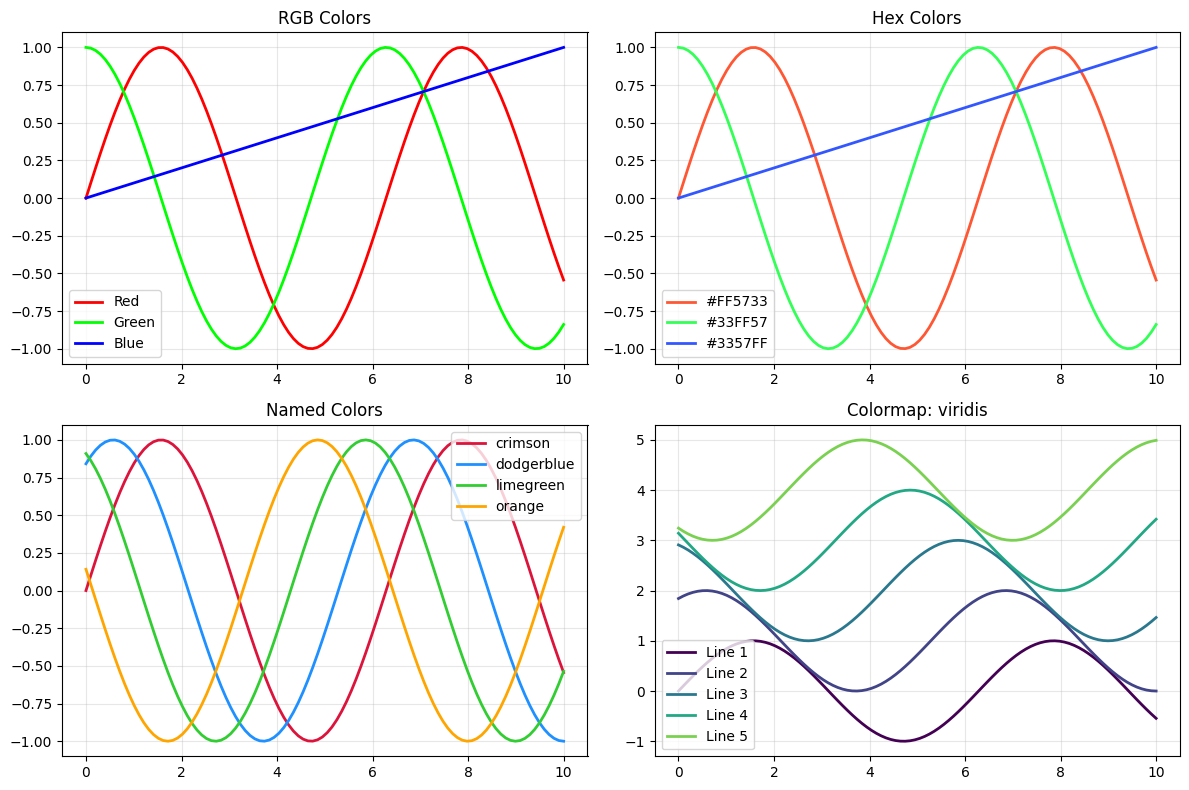

In [73]:
# Custom colors
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(0, 10, 100)

# RGB colors
ax = axes[0, 0]
ax.plot(x, np.sin(x), color=(1, 0, 0), linewidth=2, label='Red')
ax.plot(x, np.cos(x), color=(0, 1, 0), linewidth=2, label='Green')
ax.plot(x, x/10, color=(0, 0, 1), linewidth=2, label='Blue')
ax.set_title('RGB Colors')
ax.legend()
ax.grid(True, alpha=0.3)

# Hex colors
ax = axes[0, 1]
ax.plot(x, np.sin(x), color='#FF5733', linewidth=2, label='#FF5733')
ax.plot(x, np.cos(x), color='#33FF57', linewidth=2, label='#33FF57')
ax.plot(x, x/10, color='#3357FF', linewidth=2, label='#3357FF')
ax.set_title('Hex Colors')
ax.legend()
ax.grid(True, alpha=0.3)

# Named colors
ax = axes[1, 0]
colors = ['crimson', 'dodgerblue', 'limegreen', 'orange']
for i, color in enumerate(colors):
    ax.plot(x, np.sin(x + i), label=color, linewidth=2, color=color)
ax.set_title('Named Colors')
ax.legend()
ax.grid(True, alpha=0.3)

# Colormaps
ax = axes[1, 1]
cmap = plt.cm.viridis
for i in range(5):
    ax.plot(x, np.sin(x + i) + i, color=cmap(i/5), linewidth=2, label=f'Line {i+1}')
ax.set_title('Colormap: viridis')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


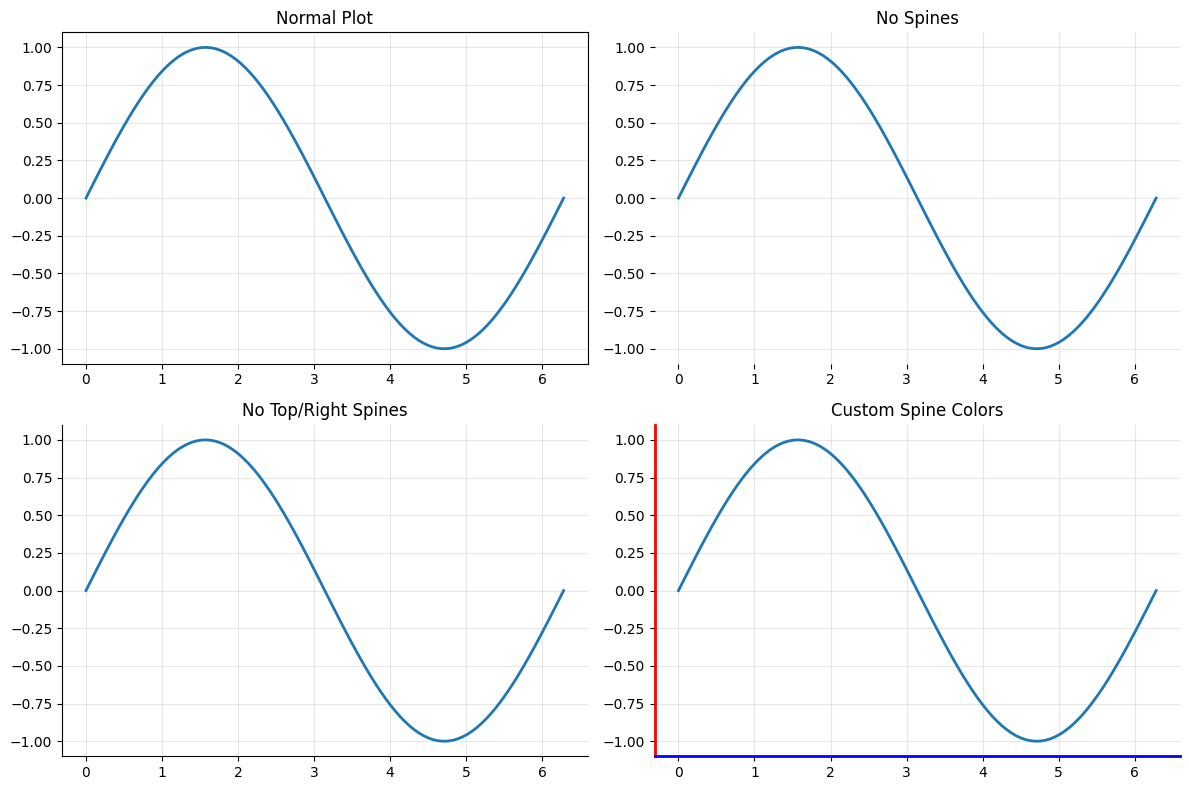

In [74]:
# Removing spines and customizing appearance
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

# Normal plot
ax = axes[0, 0]
ax.plot(x, y, linewidth=2)
ax.set_title('Normal Plot')
ax.grid(True, alpha=0.3)

# Remove all spines
ax = axes[0, 1]
ax.plot(x, y, linewidth=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title('No Spines')
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax = axes[1, 0]
ax.plot(x, y, linewidth=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('No Top/Right Spines')
ax.grid(True, alpha=0.3)

# Custom spine colors and widths
ax = axes[1, 1]
ax.plot(x, y, linewidth=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('red')
ax.spines['bottom'].set_color('blue')
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.set_title('Custom Spine Colors')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


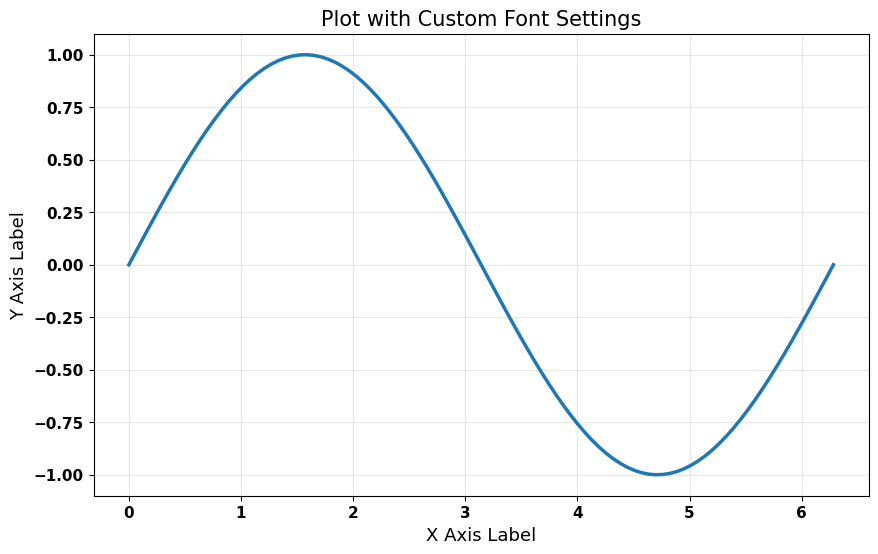

In [75]:
# Custom fonts via rcParams
from matplotlib import rcParams

# Save original rcParams
original_rcparams = rcParams.copy()

# Set custom font and size
rcParams['font.size'] = 12
rcParams['font.weight'] = 'bold'
rcParams['axes.labelsize'] = 13
rcParams['axes.titlesize'] = 15
rcParams['xtick.labelsize'] = 11
rcParams['ytick.labelsize'] = 11

fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 2*np.pi, 100)
ax.plot(x, np.sin(x), linewidth=2.5)
ax.set_xlabel('X Axis Label')
ax.set_ylabel('Y Axis Label')
ax.set_title('Plot with Custom Font Settings')
ax.grid(True, alpha=0.3)

plt.show()

# Restore original rcParams
rcParams.update(original_rcparams)


## 12. Annotations & Text

Add text and annotations to highlight features.


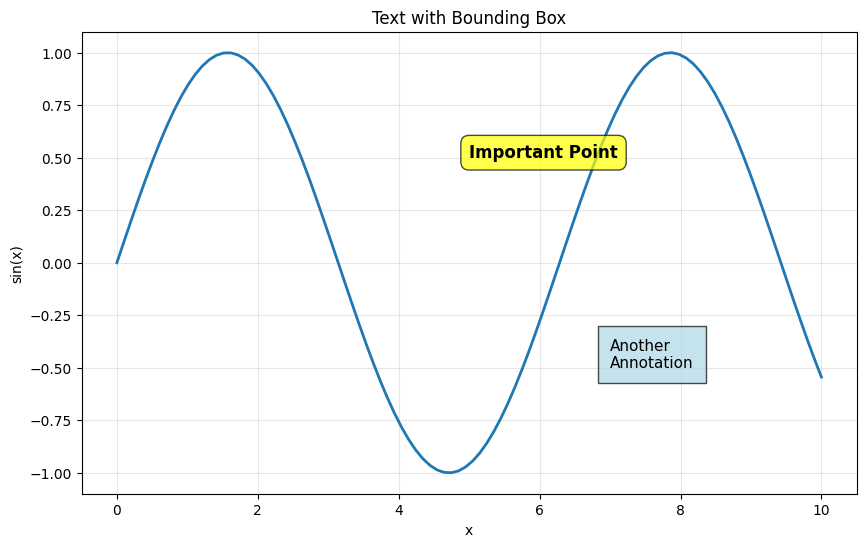

In [76]:
# Text with bounding box
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), linewidth=2)

# Add text with bbox
ax.text(5, 0.5, 'Important Point', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7, edgecolor='black'))

ax.text(7, -0.5, 'Another\nAnnotation', fontsize=11,
        bbox=dict(boxstyle='square,pad=0.8', facecolor='lightblue', alpha=0.7))

ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.set_title('Text with Bounding Box')
ax.grid(True, alpha=0.3)
plt.show()

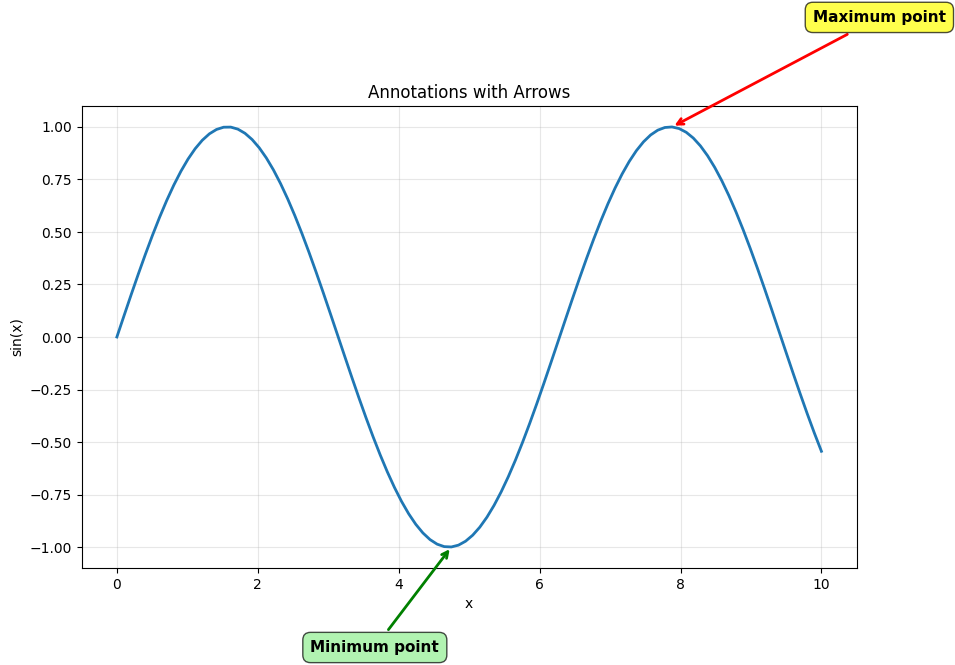

In [77]:
# Annotations with arrows
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
y = np.sin(x)
ax.plot(x, y, linewidth=2)

# Find maximum
max_idx = np.argmax(y)
max_x = x[max_idx]
max_y = y[max_idx]

# Annotate maximum
ax.annotate('Maximum point', xy=(max_x, max_y), xytext=(max_x + 2, max_y + 0.5),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'))

# Annotate minimum
min_idx = np.argmin(y)
min_x = x[min_idx]
min_y = y[min_idx]

ax.annotate('Minimum point', xy=(min_x, min_y), xytext=(min_x - 2, min_y - 0.5),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))

ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.set_title('Annotations with Arrows')
ax.grid(True, alpha=0.3)
plt.show()


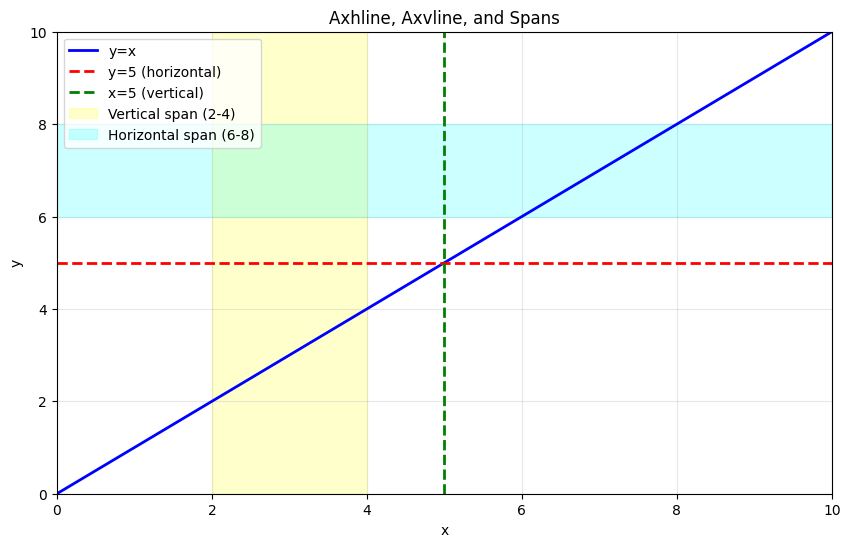

In [78]:
# Horizontal/vertical lines and spans
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)
ax.plot(x, x, 'b-', linewidth=2, label='y=x')

# Horizontal line
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, label='y=5 (horizontal)')

# Vertical line
ax.axvline(x=5, color='green', linestyle='--', linewidth=2, label='x=5 (vertical)')

# Vertical span
ax.axvspan(2, 4, alpha=0.2, color='yellow', label='Vertical span (2-4)')

# Horizontal span
ax.axhspan(6, 8, alpha=0.2, color='cyan', label='Horizontal span (6-8)')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_title('Axhline, Axvline, and Spans')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()


## 13. Saving Figures

Save figures in various formats.


Saved: /tmp/plot_demo.png
Saved: /tmp/plot_demo.pdf
Saved: /tmp/plot_demo.svg
Saved: /tmp/plot_demo_transparent.png


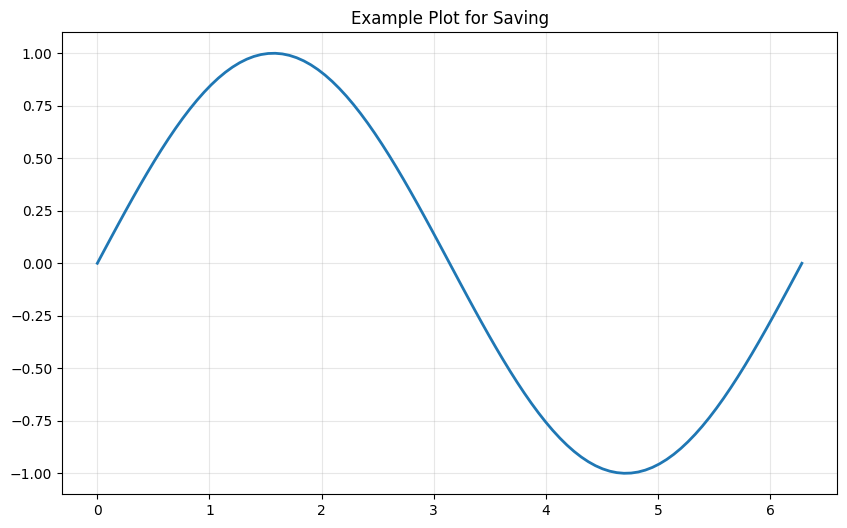


All files saved to /tmp


In [79]:
# Savefig examples
import os

# Create /tmp directory for demo if needed
os.makedirs('/tmp', exist_ok=True)

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
x = np.linspace(0, 2*np.pi, 100)
axes.plot(x, np.sin(x), linewidth=2)
axes.set_title('Example Plot for Saving')
axes.grid(True, alpha=0.3)

# Save as PNG (default)
fig.savefig('/tmp/plot_demo.png', dpi=150, bbox_inches='tight')
print("Saved: /tmp/plot_demo.png")

# Save as PDF
fig.savefig('/tmp/plot_demo.pdf', dpi=300, bbox_inches='tight')
print("Saved: /tmp/plot_demo.pdf")

# Save as SVG
fig.savefig('/tmp/plot_demo.svg', dpi=150, bbox_inches='tight')
print("Saved: /tmp/plot_demo.svg")

# Save with transparency
fig.savefig('/tmp/plot_demo_transparent.png', dpi=150, bbox_inches='tight', transparent=True)
print("Saved: /tmp/plot_demo_transparent.png")

plt.show()

print("\nAll files saved to /tmp")


## 14. Seaborn Integration

Seaborn builds on matplotlib for statistical visualizations.


In [80]:
# Install seaborn
import subprocess
import sys

try:
    import seaborn as sns
    print("Seaborn already installed")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "-q"])
    import seaborn as sns
    print("Seaborn installed successfully")


Seaborn already installed


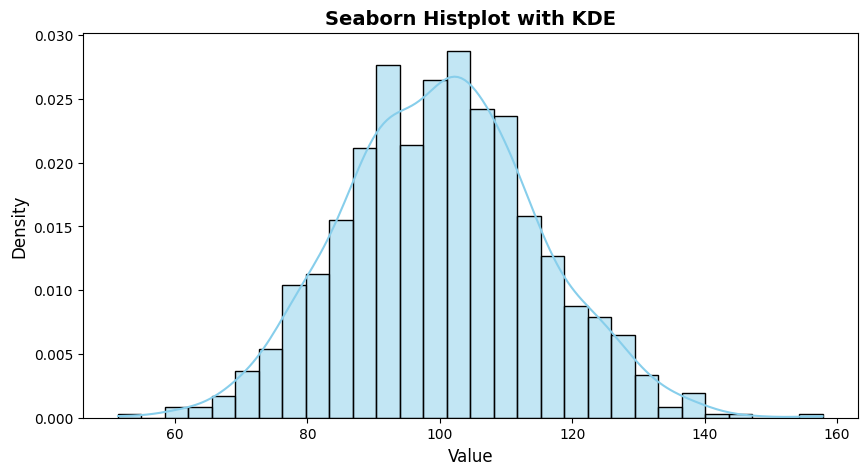

In [81]:
# Seaborn histplot with KDE
import seaborn as sns

np.random.seed(42)
data = np.random.normal(100, 15, 1000)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data, bins=30, kde=True, stat='density', color='skyblue',
             edgecolor='black', ax=ax)
ax.set_xlabel('Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Seaborn Histplot with KDE', fontsize=14, fontweight='bold')
plt.show()


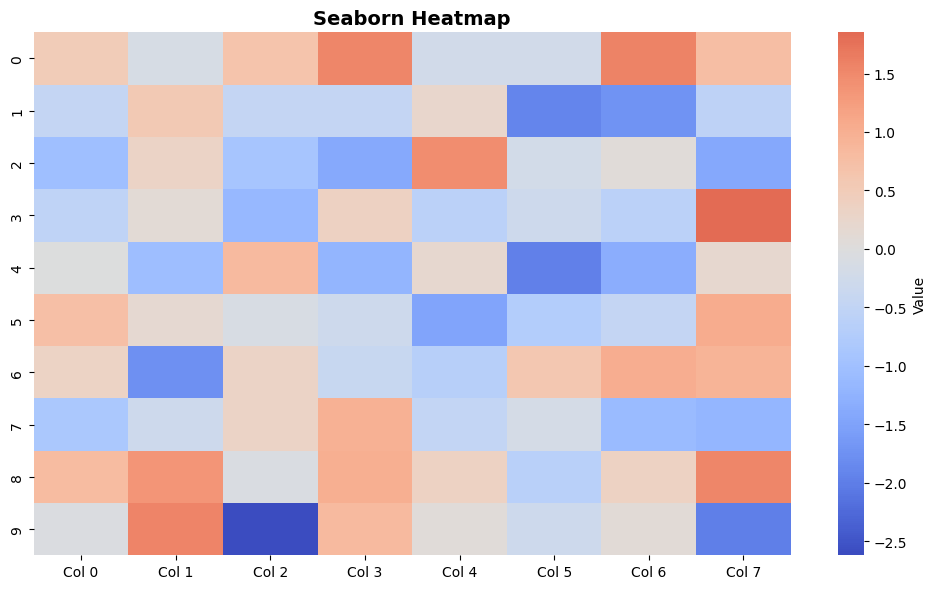

In [82]:
# Seaborn heatmap
import seaborn as sns

np.random.seed(42)
data = np.random.randn(10, 8)
df = pd.DataFrame(data, columns=[f'Col {i}' for i in range(8)])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Value'}, ax=ax)
ax.set_title('Seaborn Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


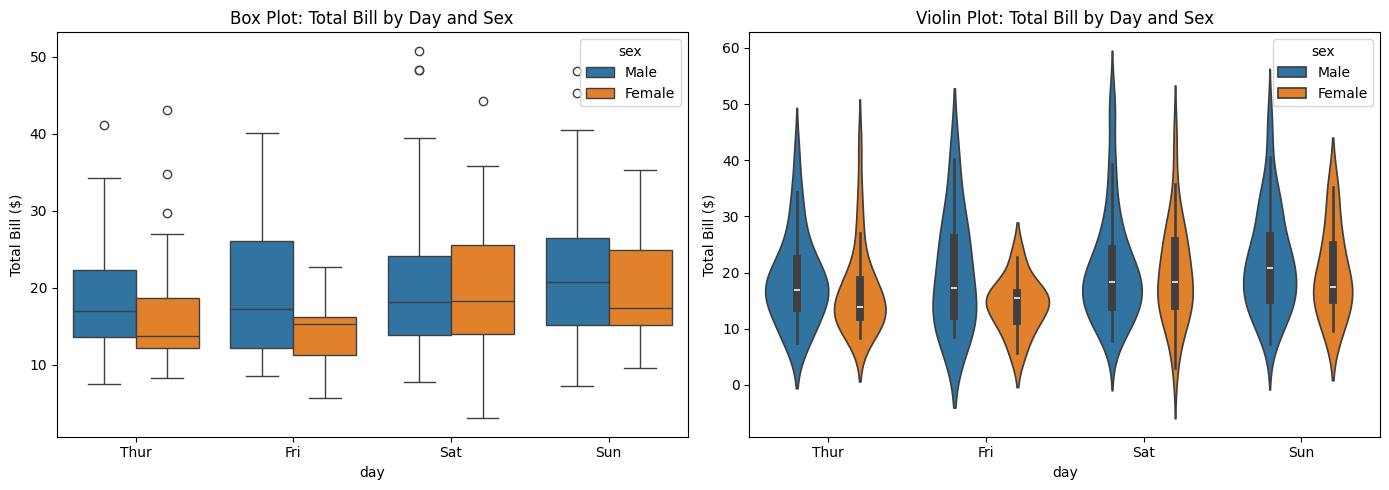

In [83]:
# Seaborn with tips dataset
import seaborn as sns

# Load tips dataset
tips = sns.load_dataset('tips')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by day and sex
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0])
axes[0].set_title('Box Plot: Total Bill by Day and Sex')
axes[0].set_ylabel('Total Bill ($)')

# Violin plot
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1])
axes[1].set_title('Violin Plot: Total Bill by Day and Sex')
axes[1].set_ylabel('Total Bill ($)')

plt.tight_layout()
plt.show()


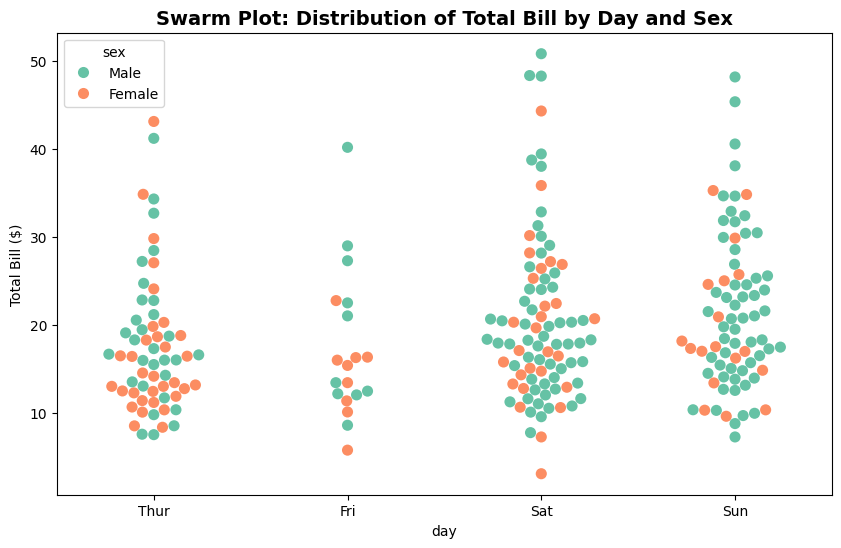

In [84]:
# Seaborn categorical scatter plot (swarm plot)
import seaborn as sns

tips = sns.load_dataset('tips')

fig, ax = plt.subplots(figsize=(10, 6))
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', size=8, ax=ax, palette='Set2')
ax.set_title('Swarm Plot: Distribution of Total Bill by Day and Sex', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Bill ($)')
plt.show()


## 15. Practice Exercises

Exercises to practice matplotlib skills.


In [85]:
# Exercise 1: Create a figure with 2x2 subplots showing different distributions
# TODO: Create histogram, box plot, violin plot, and scatter plot of generated data

print("Exercise 1: Create a 2x2 grid with different plot types")
print("\nStarter code:")
print('''
np.random.seed(42)
data = np.random.normal(100, 15, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [1] Histogram in axes[0, 0]
# axes[0, 0].hist(data, bins=30, ...)

# [2] Box plot in axes[0, 1]
# axes[0, 1].boxplot([data, ...])

# [3] Violin plot in axes[1, 0]
# axes[1, 0].violinplot([data, ...])

# [4] Scatter in axes[1, 1]
# axes[1, 1].scatter(x, y)

plt.tight_layout()
plt.show()
''')


Exercise 1: Create a 2x2 grid with different plot types

Starter code:

np.random.seed(42)
data = np.random.normal(100, 15, 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# [1] Histogram in axes[0, 0]
# axes[0, 0].hist(data, bins=30, ...)

# [2] Box plot in axes[0, 1]
# axes[0, 1].boxplot([data, ...])

# [3] Violin plot in axes[1, 0]
# axes[1, 0].violinplot([data, ...])

# [4] Scatter in axes[1, 1]
# axes[1, 1].scatter(x, y)

plt.tight_layout()
plt.show()



In [86]:
# Exercise 2: Create a line plot with multiple lines, legend, and annotations
# TODO: Plot multiple mathematical functions with proper labeling and annotations

print("Exercise 2: Multi-line plot with annotations")
print("\nStarter code:")
print('''
x = np.linspace(0, 2*np.pi, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot sine, cosine, and tangent (clipped)
# ax.plot(x, np.sin(x), label='sin(x)')
# ax.plot(x, np.cos(x), label='cos(x)')

# Add title, labels, grid, legend
# ax.set_title('...')
# ax.set_xlabel('...')
# ax.set_ylabel('...')
# ax.grid(True, alpha=0.3)
# ax.legend()

plt.show()
''')


Exercise 2: Multi-line plot with annotations

Starter code:

x = np.linspace(0, 2*np.pi, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot sine, cosine, and tangent (clipped)
# ax.plot(x, np.sin(x), label='sin(x)')
# ax.plot(x, np.cos(x), label='cos(x)')

# Add title, labels, grid, legend
# ax.set_title('...')
# ax.set_xlabel('...')
# ax.set_ylabel('...')
# ax.grid(True, alpha=0.3)
# ax.legend()

plt.show()



In [87]:
# Exercise 3: Create a grouped bar chart with categorical data
# TODO: Create a grouped bar chart showing sales data by product and quarter

print("Exercise 3: Grouped bar chart")
print("\nStarter code:")
print('''
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [45, 52, 48, 63]
product_b = [38, 41, 55, 70]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

# ax.bar(x - width/2, product_a, width, label='Product A')
# ax.bar(x + width/2, product_b, width, label='Product B')

# ax.set_xlabel('Quarter')
# ax.set_ylabel('Sales')
# ax.set_title('Sales by Product and Quarter')
# ax.set_xticks(x)
# ax.set_xticklabels(categories)
# ax.legend()

plt.show()
''')


Exercise 3: Grouped bar chart

Starter code:

categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [45, 52, 48, 63]
product_b = [38, 41, 55, 70]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

# ax.bar(x - width/2, product_a, width, label='Product A')
# ax.bar(x + width/2, product_b, width, label='Product B')

# ax.set_xlabel('Quarter')
# ax.set_ylabel('Sales')
# ax.set_title('Sales by Product and Quarter')
# ax.set_xticks(x)
# ax.set_xticklabels(categories)
# ax.legend()

plt.show()



In [88]:
# Exercise 4: Create a scatter plot with multiple categories and a regression line
# TODO: Generate data with 3 categories and fit a regression line through all points

print("Exercise 4: Scatter plot with regression")
print("\nStarter code:")
print('''
np.random.seed(42)
x = np.random.uniform(0, 10, 100)
y = 2*x + 3 + np.random.normal(0, 2, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
# ax.scatter(x, y, alpha=0.6, s=50)

# Fit and plot regression line
# coeffs = np.polyfit(x, y, 1)
# poly = np.poly1d(coeffs)
# x_smooth = np.linspace(x.min(), x.max(), 100)
# ax.plot(x_smooth, poly(x_smooth), 'r-', linewidth=2)

# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_title('Scatter with Regression Line')
# ax.grid(True, alpha=0.3)

plt.show()
''')


Exercise 4: Scatter plot with regression

Starter code:

np.random.seed(42)
x = np.random.uniform(0, 10, 100)
y = 2*x + 3 + np.random.normal(0, 2, 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
# ax.scatter(x, y, alpha=0.6, s=50)

# Fit and plot regression line
# coeffs = np.polyfit(x, y, 1)
# poly = np.poly1d(coeffs)
# x_smooth = np.linspace(x.min(), x.max(), 100)
# ax.plot(x_smooth, poly(x_smooth), 'r-', linewidth=2)

# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_title('Scatter with Regression Line')
# ax.grid(True, alpha=0.3)

plt.show()



In [89]:
# Exercise 5: Create a pie chart showing composition with styled appearance
# TODO: Create a pie chart with custom colors, exploded slice, and percentage labels

print("Exercise 5: Styled pie chart")
print("\nStarter code:")
print('''
sizes = [30, 25, 20, 15, 10]
labels = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
explode = (0.1, 0, 0, 0, 0)  # Explode first slice

fig, ax = plt.subplots(figsize=(10, 7))

# ax.pie(sizes, labels=labels, colors=colors, explode=explode,
#        autopct='%1.1f%%', shadow=True, startangle=90)

ax.set_title('Composition Distribution')

plt.show()
''')


Exercise 5: Styled pie chart

Starter code:

sizes = [30, 25, 20, 15, 10]
labels = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
explode = (0.1, 0, 0, 0, 0)  # Explode first slice

fig, ax = plt.subplots(figsize=(10, 7))

# ax.pie(sizes, labels=labels, colors=colors, explode=explode,
#        autopct='%1.1f%%', shadow=True, startangle=90)

ax.set_title('Composition Distribution')

plt.show()



## Summary

You've learned matplotlib fundamentals:
- Creating figures and axes
- Common plot types (line, bar, scatter, histogram, etc.)
- Customization options (colors, styles, annotations)
- Subplots and layouts
- Integration with seaborn
- Saving figures

**Next steps:**
- Explore the matplotlib gallery: https://matplotlib.org/stable/gallery/
- Practice with real datasets
- Combine techniques for complex visualizations
- Dive deeper into specific plot types
